In [1]:
from description import DescriptionEntry, row_to_object
import csv

In [17]:
# Create a list to store all your objects
all_entries = []

# Open the CSV file
# Ensure the filename matches your actual file
filename = 'results-updated-eval.csv' 

with open(filename, mode='r', encoding='utf-8') as csvfile:
    # DictReader automatically uses the header row as keys
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        # Convert row to object
        entry = row_to_object(row)
        all_entries.append(entry)

# --- Example: Loop through and print specific attributes ---
for entry in all_entries[:3]: # Printing just first 3 to avoid cluttering notebook
    print("-" * 50)
    print(f"Test ID:      {entry.test_id}")
    print(f"Dataset:      {entry.dataset_name} (ID: {entry.dataset_id})")
    print(f"Prompt:       {entry.prompt}")
    print(f"Strategy:     {entry.extraction_strategy}")
    
    print("\n--- Profile Stats (from JSON) ---")
    print(f"Summary:      {entry.profile_stats.summary[:50]}...") # Truncated for display
    print(f"Src Length:   {entry.profile_stats.source_length}")
    
    print("\n--- Scores ---")
    print(f"Completeness: {entry.completeness_score}")
    print(f"Readability:  {entry.readability_score}")
    
    print("\n--- BERT Metrics ---")
    # Accessing dictionary values
    print(f"Precision:    {entry.bert_metrics['precision']}")
    print(f"F1:           {entry.bert_metrics['f1']}")
    
    print("\n--- Strict Coverage ---")
    print(f"Overall:      {entry.strict_coverage['overall']}")
    print(f"Provenance:   {entry.strict_coverage['provenance']}")
    print("-" * 50)

FileNotFoundError: [Errno 2] No such file or directory: 'results-updated-eval.csv'

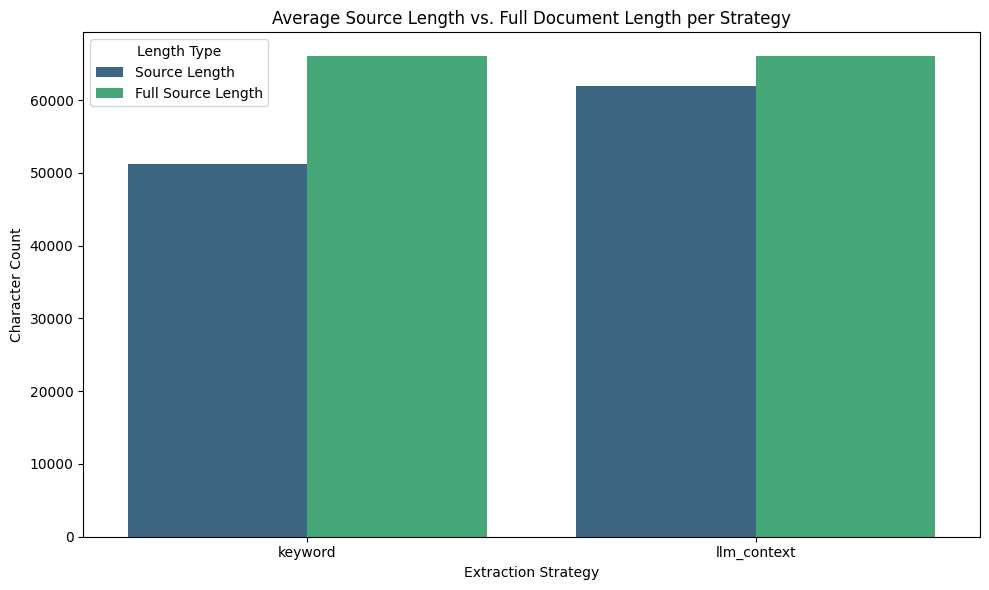

  Extraction Strategy  Source Length  Full Source Length
0             keyword        51199.2             66025.4
1         llm_context        61890.3             66025.4


In [ ]:
# --- 3. Process Data using Objects ---
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('results-updated-1-eval.csv')

entries = [row_to_object(row) for index, row in df.iterrows()]

# --- 4. Prepare for Plotting ---
# We extract the specific fields needed for the length comparison
plot_data = []
for entry in entries:
    plot_data.append({
        'Extraction Strategy': entry.extraction_strategy,
        'Source Length': entry.profile_stats.source_length,
        'Full Source Length': entry.profile_stats.full_source_length
    })

plot_df = pd.DataFrame(plot_data)

# Aggregate by Strategy (calculate mean) in case there are multiple entries
agg_df = plot_df.groupby('Extraction Strategy').mean().reset_index()

# Melt for Seaborn (Long format)
melted_df = agg_df.melt(
    id_vars='Extraction Strategy',
    value_vars=['Source Length', 'Full Source Length'],
    var_name='Length Type',
    value_name='Character Count'
)

# --- 5. Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=melted_df,
    x='Extraction Strategy',
    y='Character Count',
    hue='Length Type',
    palette='viridis'
)

plt.title('Average Source Length vs. Full Document Length per Strategy')
plt.ylabel('Character Count')
plt.xlabel('Extraction Strategy')
plt.tight_layout()
plt.show()

# Print Table for verification
print(agg_df)

In [10]:
import pandas as pd
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


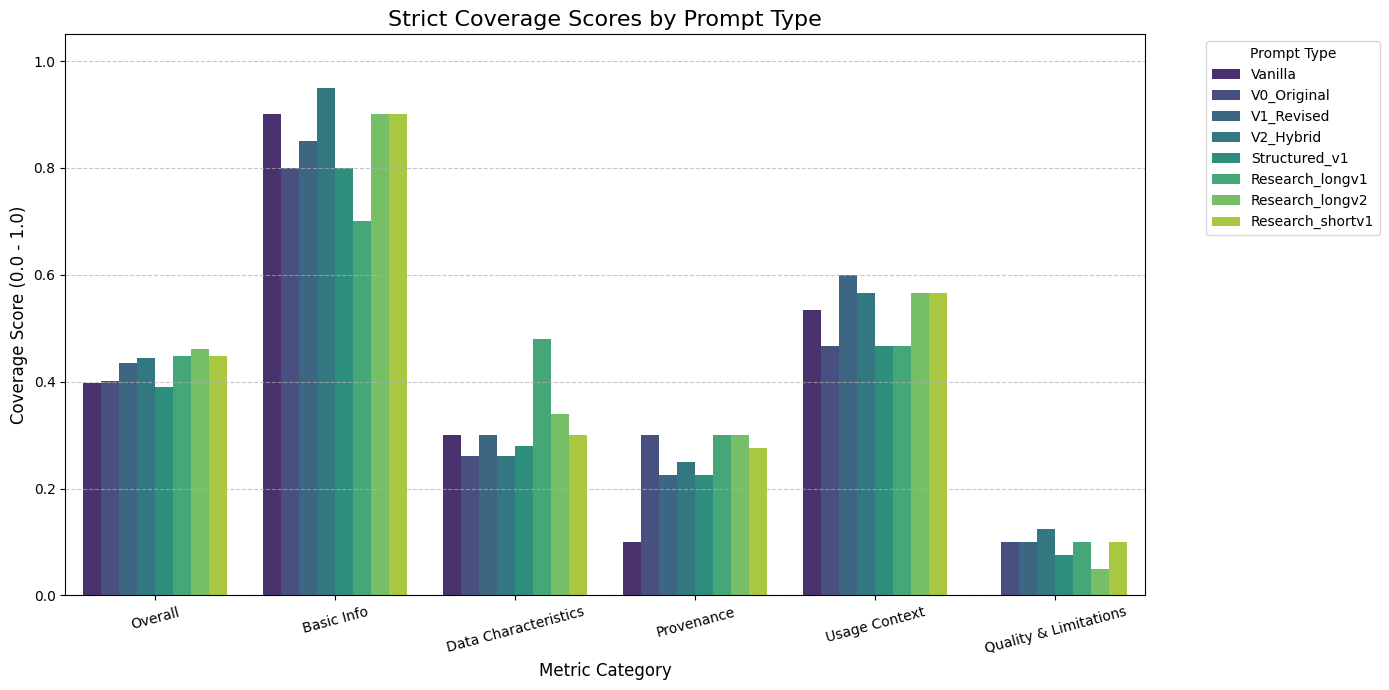

Average Strict Coverage Scores per Prompt Type:


,Overall,Basic Info,Data Characteristics,Provenance,Usage Context,Quality & Limitations
Prompt Type,,,,,,
Research_longv1,0.447333,0.70,0.48,0.300,0.466667,0.100
Research_longv2,0.460333,0.90,0.34,0.300,0.566667,0.050
Research_shortv1,0.448333,0.90,0.30,0.275,0.566667,0.100
Structured_v1,0.389833,0.80,0.28,0.225,0.466667,0.075
V0_Original,0.401333,0.80,0.26,0.300,0.466667,0.100
V1_Revised,0.435000,0.85,0.30,0.225,0.600000,0.100
V2_Hybrid,0.443833,0.95,0.26,0.250,0.566667,0.125
Vanilla,0.396667,0.90,0.30,0.100,0.533333,0.000


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import csv

filename = 'results-systematic-eval.csv'
all_entries = []

# 1. Load Data
with open(filename, mode='r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    
    # Keep loop indented inside 'with' block
    for row in reader:
        entry = row_to_object(row)
        all_entries.append(entry)

coverage_data = []

# 2. Extract Data grouped by Prompt Type
for entry in all_entries:
    cov = entry.strict_coverage
    
    # Handle empty prompt types (e.g. for Vanilla rows)
    p_type = entry.prompt if entry.prompt else "Vanilla"

    coverage_data.append({
        'Prompt Type': p_type,  # Changed from Strategy
        'Overall': cov['overall'],
        'Basic Info': cov['basic_info'],
        'Data Characteristics': cov['data_characteristics'],
        'Provenance': cov['provenance'],
        'Usage Context': cov['usage_context'],
        'Quality & Limitations': cov['quality_and_limitations']
    })

# 3. Create DataFrame
df_cov = pd.DataFrame(coverage_data)

# 4. Reshape for Plotting
df_melted = df_cov.melt(
    id_vars='Prompt Type', 
    var_name='Coverage Metric', 
    value_name='Score'
)

# 5. Create the Plot
plt.figure(figsize=(14, 7))

order = ['Overall', 'Basic Info', 'Data Characteristics', 'Provenance', 'Usage Context', 'Quality & Limitations']

sns.barplot(
    data=df_melted,
    x='Coverage Metric',
    y='Score',
    hue='Prompt Type',  # Changed to Prompt Type
    order=order,
    palette='viridis',
    errorbar=None
)

plt.title('Strict Coverage Scores by Prompt Type', fontsize=16)
plt.ylabel('Coverage Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Metric Category', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Prompt Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 6. Print Summary Table
print("Average Strict Coverage Scores per Prompt Type:")
summary_table = df_cov.groupby('Prompt Type').mean()
display(summary_table[order])

In [13]:
length_data = []

for entry in entries:
    src_len = entry.profile_stats.source_length
    full_len = entry.profile_stats.full_source_length
    
    # Avoid division by zero
    ratio = (src_len / full_len) * 100 if full_len > 0 else 0
    
    length_data.append({
        'Strategy': entry.extraction_strategy,
        'Context Sent (Chars)': src_len,
        'Full Paper (Chars)': full_len,
        'Ratio (%)': ratio
    })

# 2. Convert to DataFrame
df_len = pd.DataFrame(length_data)

# 3. Create the Summary Table (Averages)
# We group by strategy to see the "Average Cost" of each approach
summary_table = df_len.groupby('Strategy').mean().reset_index()

# Formatting for readability
summary_table['Context Sent (Chars)'] = summary_table['Context Sent (Chars)'].map('{:,.0f}'.format)
summary_table['Full Paper (Chars)'] = summary_table['Full Paper (Chars)'].map('{:,.0f}'.format)
summary_table['Ratio (%)'] = summary_table['Ratio (%)'].map('{:.1f}%'.format)

# Rename columns for the final display
summary_table = summary_table.rename(columns={
    'Strategy': 'Extraction Strategy',
    'Context Sent (Chars)': 'Avg Context Sent',
    'Full Paper (Chars)': 'Avg Full Paper Length'
})

print("--- Context vs. Full Text Comparison ---")
display(summary_table)

--- Context vs. Full Text Comparison ---


,Extraction Strategy,Avg Context Sent,Avg Full Paper Length,Ratio (%)
0,keyword,"51,199","66,025",78.5%
1,llm_context,"61,890","66,025",94.1%


In [18]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parse the text data
data = []

for entry in entries:
    entry = entry.strip()
    if not entry: continue
    
    # Extract Prompt
    prompt_match = re.search(r'Prompt:\s+(.+)', entry)
    prompt = prompt_match.group(1).strip() if prompt_match else "Unknown"
    
    # Extract Scores (Overall and Provenance)
    overall_match = re.search(r'Overall:\s+([\d\.]+)', entry)
    provenance_match = re.search(r'Provenance:\s+([\d\.]+)', entry)
    
    if overall_match:
        data.append({
            'Prompt': prompt,
            'Score Type': 'Overall',
            'Score': float(overall_match.group(1))
        })
    if provenance_match:
        data.append({
            'Prompt': prompt,
            'Score Type': 'Provenance',
            'Score': float(provenance_match.group(1))
        })

# 2. Create DataFrame
df = pd.DataFrame(data)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Prompt', y='Score', hue='Score Type', alpha=0.6, errorbar=None)
sns.stripplot(data=df, x='Prompt', y='Score', hue='Score Type', dodge=True, jitter=True, color='black', alpha=0.5)
plt.title('Coverage Scores by Prompt')
plt.ylim(0, 1.05)
plt.show()

ValueError: Could not interpret value `Prompt` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>